In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
from nltk.util import ngrams
from nltk.corpus import stopwords
import nltk

In [2]:
sns.set_theme(style="whitegrid", palette="Blues_r",)
sns.set_palette(["#87CEEB"])  # globalize sky blue fill

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nkrahul\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
df = pd.read_csv(r"../data/interim/dataset.csv")

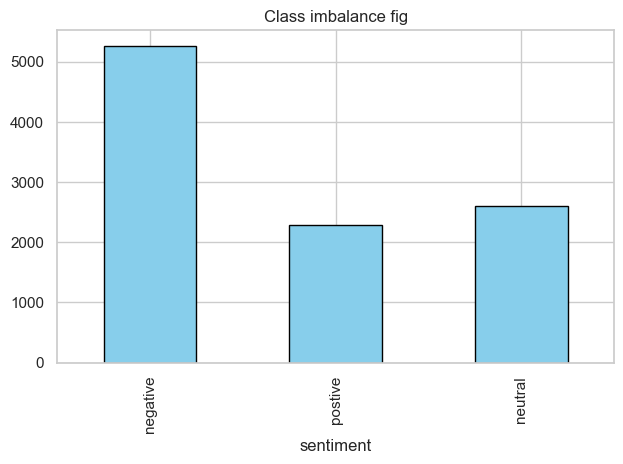

In [5]:
df.sentiment.value_counts().sort_index().plot(kind='bar', edgecolor='black')
plt.title("Class imbalance fig")
plt.xticks([0, 1, 2], labels=['negative', 'postive', 'neutral'])
plt.tight_layout()
plt.savefig(r"../reports/eda/final_dataset_class.png")
plt.show()

In [6]:
df = df[~df['text_clean'].str.contains('please remember what subreddit you are in this is unpopular opinion')]

Classes are imbalance and we can see that the negative sentiment data points are more when compared to the postive and neutral data points.

In [7]:
stop_words = set(stopwords.words('english'))

In [8]:
df['tokens'] = df['text_clean'].dropna().apply(str.split)
all_words = [word for tokens in df['tokens'].dropna() for word in tokens]

##### Top 25 Stopwords

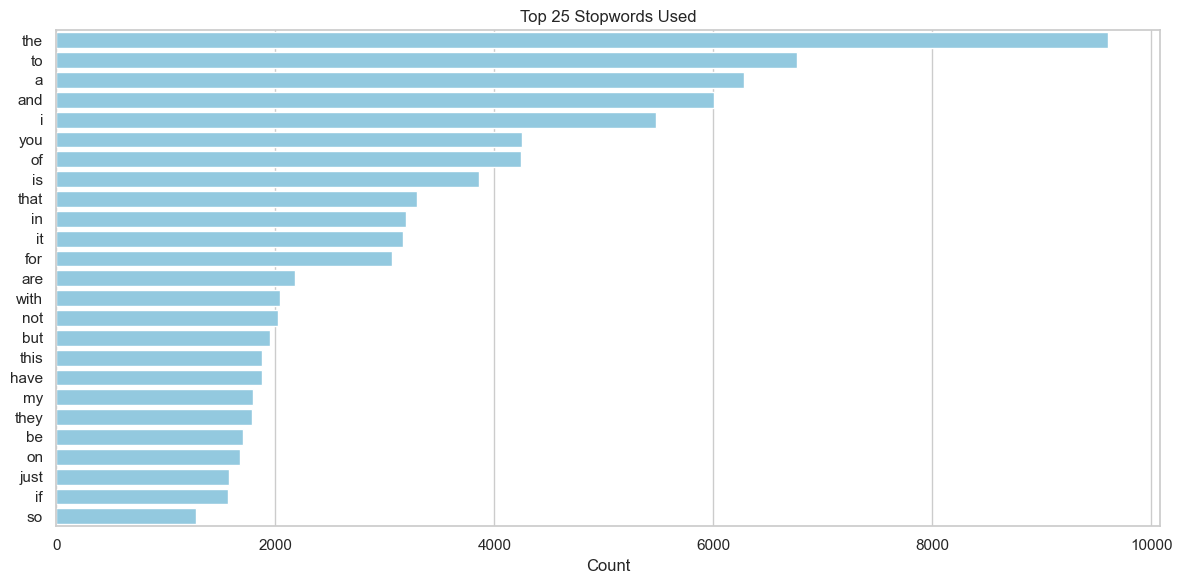

In [9]:
stop_words_used = [w for w in all_words if w in stop_words]
top_stopwords = Counter(stop_words_used).most_common(25)

words, counts = zip(*top_stopwords)
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(words))
plt.title('Top 25 Stopwords Used')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

##### Top 25 Most Used Words (without stopwords)


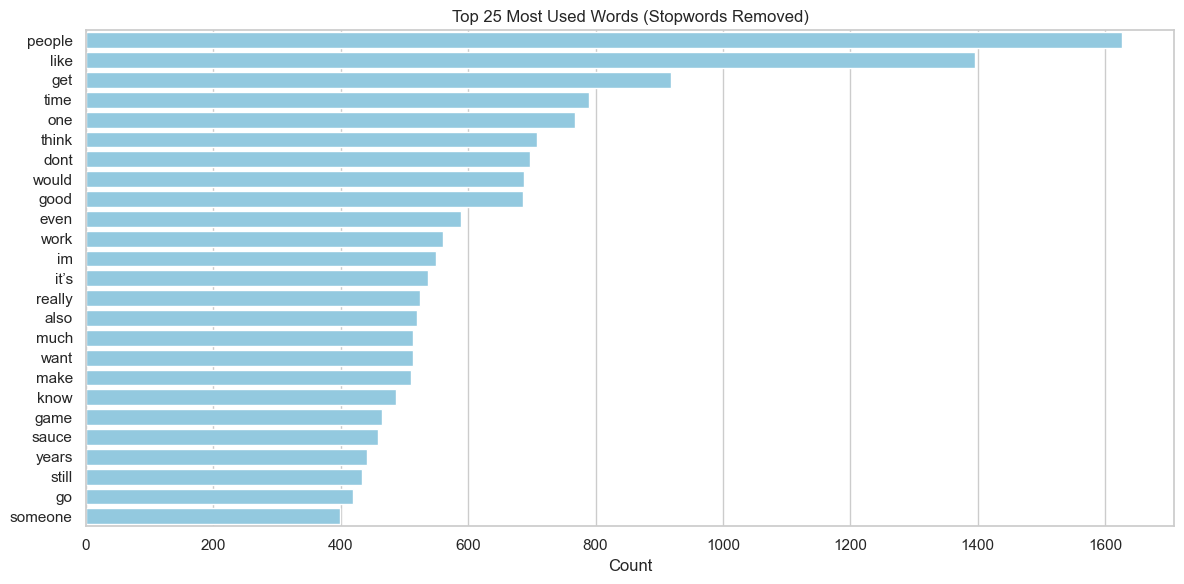

In [10]:
filtered_words = [w for w in all_words if w not in stop_words]
top_words = Counter(filtered_words).most_common(25)

words, counts = zip(*top_words)
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(words))
plt.title('Top 25 Most Used Words (Stopwords Removed)')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

##### Top 25 Bigrams

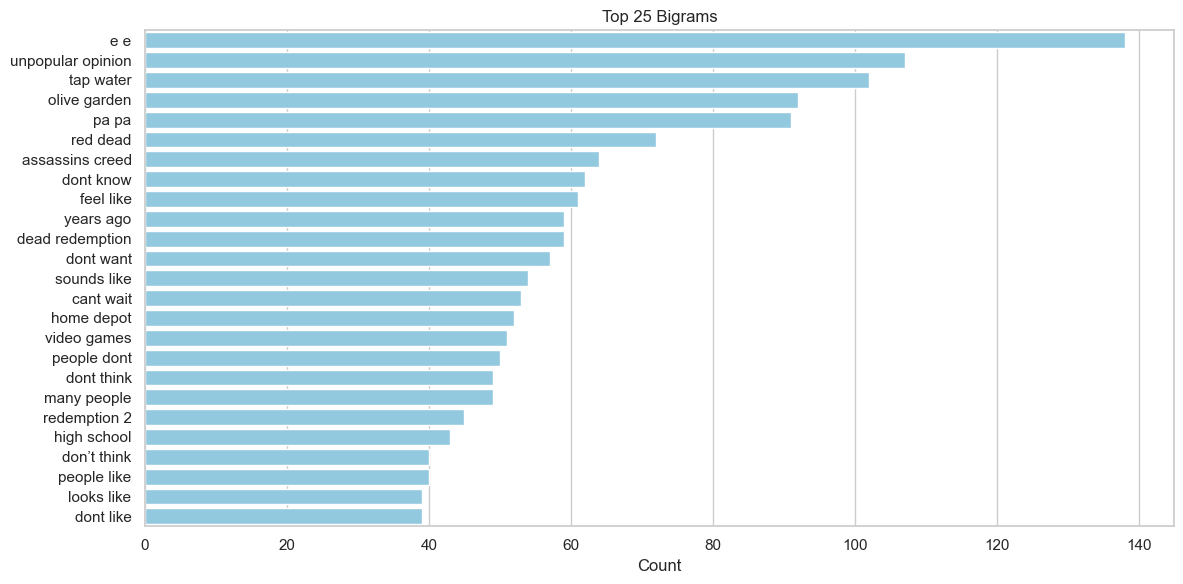

In [11]:
bigrams = list(ngrams(filtered_words, 2))
top_bigrams = Counter(bigrams).most_common(25)

labels, counts = zip(*[(" ".join(b), c) for b, c in top_bigrams])
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(labels))
plt.title('Top 25 Bigrams')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

unpopular opinion bigram is in top 2 thats because after analysis i understood that most of the data is scrapped from 
unpopular opinon sub from reddit

##### Top 25 Trigrams

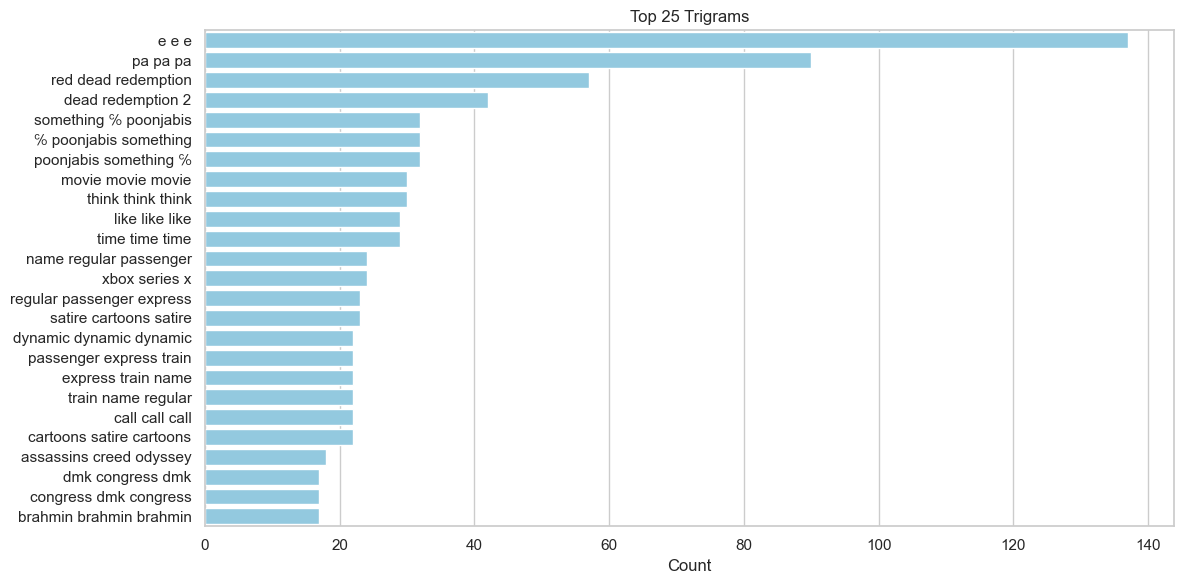

In [12]:
trigrams = list(ngrams(filtered_words, 3))
top_trigrams = Counter(trigrams).most_common(25)

labels, counts = zip(*[(" ".join(t), c) for t, c in top_trigrams])
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(labels))
plt.title('Top 25 Trigrams')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

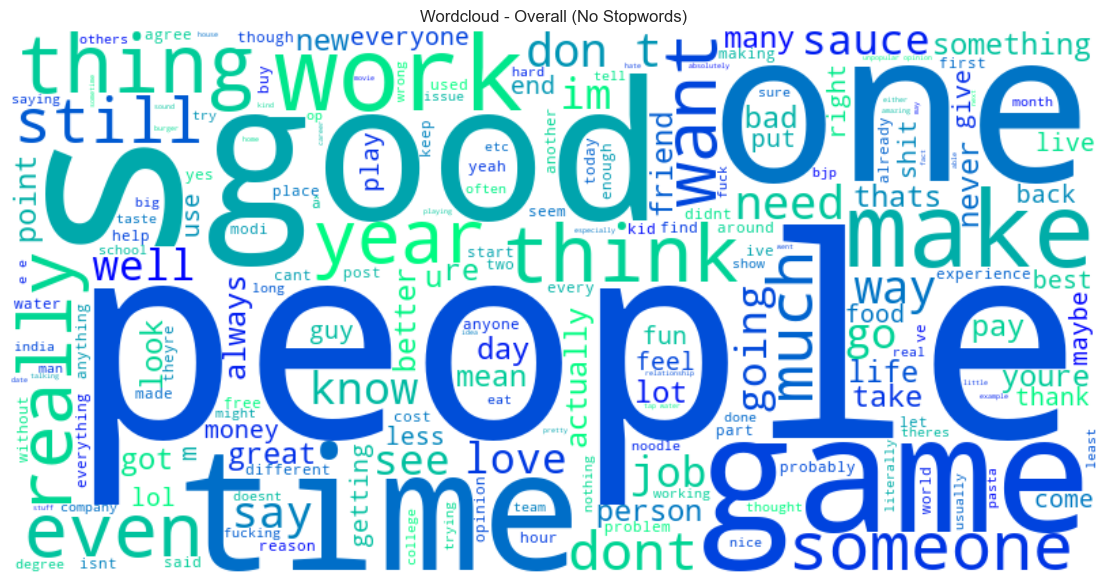

In [13]:
text = " ".join(filtered_words)
wc = WordCloud(width=800, height=400, background_color='white', colormap='winter').generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud - Overall (No Stopwords)')
plt.tight_layout()
plt.savefig(r'../reports/eda/overall_wordcloud_final_dataset.png')
plt.show()

##### Wordcloud per sentiment class

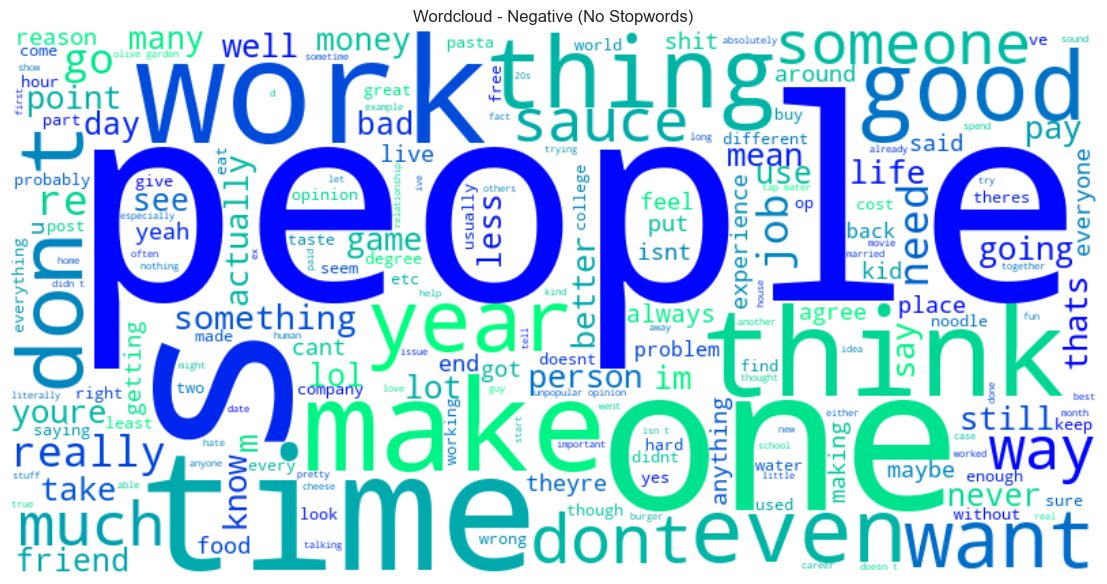

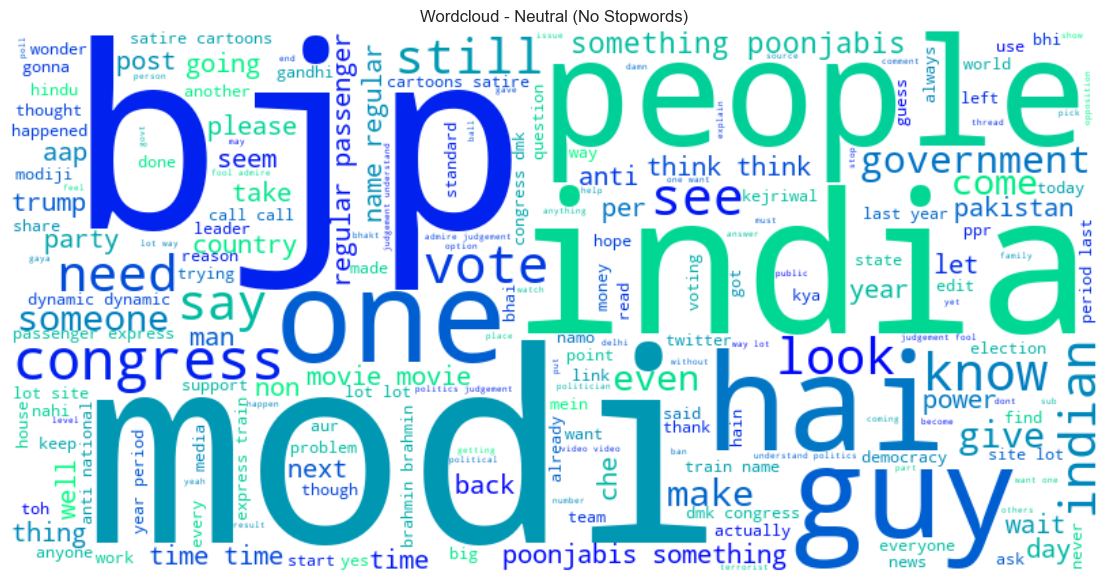

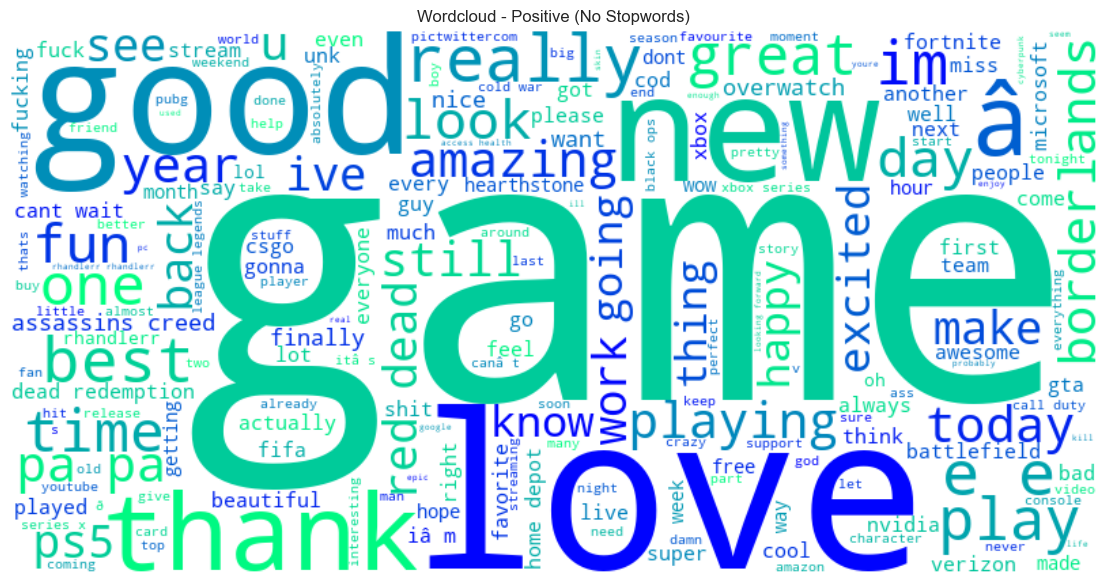

In [14]:
map = {-1 : 'Negative', 1: 'Positive', 0: 'Neutral'}
for sentiment in df['sentiment'].unique():
    subset = df[df['sentiment'] == sentiment]['tokens'].dropna()
    words = [w for tokens in subset for w in tokens if w not in stop_words]
    text = " ".join(words)

    wc = WordCloud(width=800, height=400, background_color='white', colormap='winter').generate(text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Wordcloud - {map[sentiment]} (No Stopwords)')
    plt.tight_layout()
    plt.savefig(r'../reports/eda/word_cloud_' + map[sentiment].lower() + '_sentiment' + '.png')
    plt.show()

##### Text Length Distribution


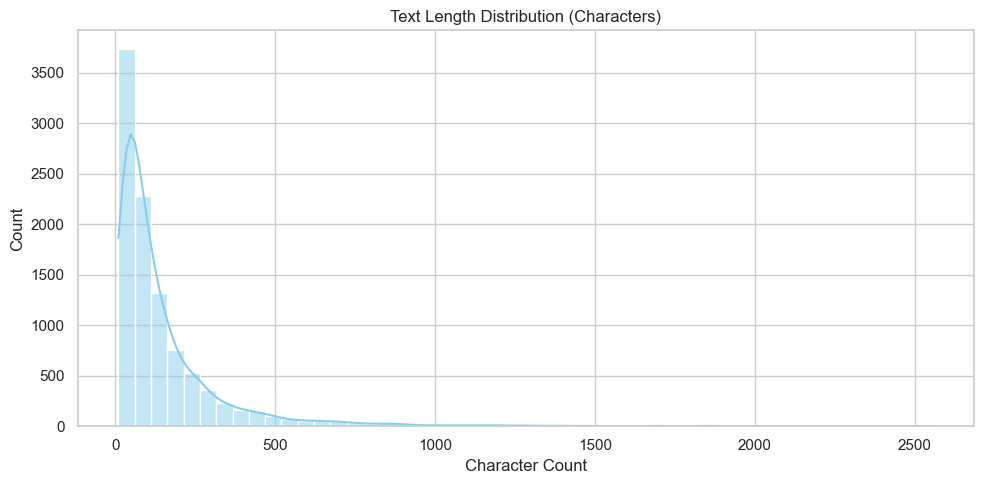

In [15]:
df['char_count'] = df['text_clean'].dropna().apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(df['char_count'], bins=50, kde=True) # type: ignore
plt.title('Text Length Distribution (Characters)')
plt.xlabel('Character Count')
plt.tight_layout()
plt.show()

There are many comments who length is 0-250 and there are even many docs who length > 500 to 1500 chars but these are very few.
The distribution is log-normal and it is expected very few comments are long and there are many comments which have few-medium char counts

##### Word Count Distribution


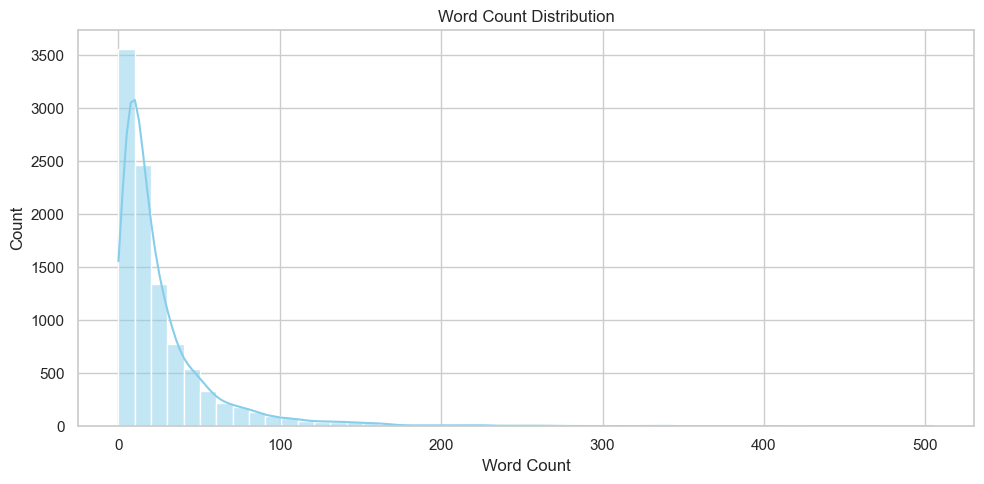

In [16]:
df['word_count'] = df['tokens'].dropna().apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.tight_layout()
plt.show()

In [17]:
df[df['text_clean'].str.contains("unpopular opinion")]

,sentiment,text_clean,tokens,char_count,word_count
54,-1,wow an actual unpopular opinion,"[wow, an, actual, unpopular, opinion]",31,5
61,-1,it’s not that deep people break up all the tim...,"[it’s, not, that, deep, people, break, up, all...",209,42
64,-1,understanding this is an unpopular opinion sub...,"[understanding, this, is, an, unpopular, opini...",166,28
149,-1,an actual unpopular opinion,"[an, actual, unpopular, opinion]",27,4
153,-1,how is this an unpopular opinion,"[how, is, this, an, unpopular, opinion]",32,6
...,...,...,...,...,...
5064,-1,hahah i have nailed the unpopular opinion awar...,"[hahah, i, have, nailed, the, unpopular, opini...",55,10
5069,-1,for me it is self control haha there was a boa...,"[for, me, it, is, self, control, haha, there, ...",409,86
5089,-1,i was expecting more people to agree with you ...,"[i, was, expecting, more, people, to, agree, w...",122,24
5146,-1,finally some unpopular opinion that i actually...,"[finally, some, unpopular, opinion, that, i, a...",265,50


##### Average Word Length

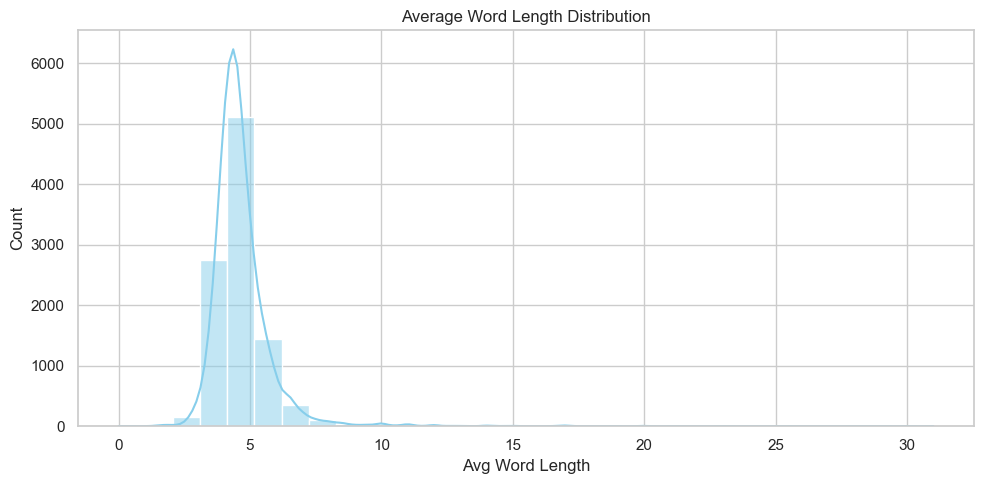

In [18]:
df['avg_word_len'] = df['tokens'].dropna().apply(
    lambda tokens: sum(len(w) for w in tokens) / len(tokens) if tokens else 0
)

plt.figure(figsize=(10, 5))
sns.histplot(df['avg_word_len'], bins=30, kde=True)
plt.title('Average Word Length Distribution')
plt.xlabel('Avg Word Length')
plt.tight_layout()
plt.show()

##### Word count by sentiment

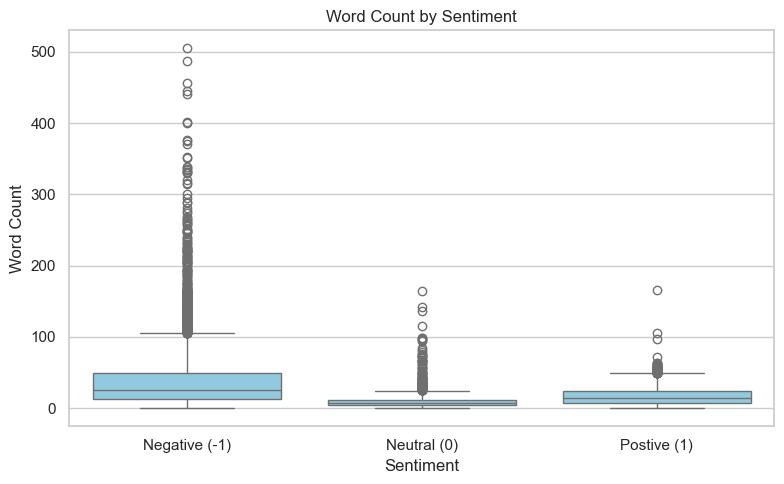

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='sentiment', y='word_count')
plt.xticks([0, 1, 2], ['Negative (-1)', 'Neutral (0)', 'Postive (1)'])
plt.title('Word Count by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Word Count')
plt.tight_layout()
plt.show()

I see negative sentiment comments has more word counts than other stating that people are trying to explain more as in why it is so.
I can see that 50% of the data has word counts for both neg and pos btw 0-50 word counts.

In [20]:
for sentiment in df['sentiment'].unique():
    subset = df[df['sentiment'] == sentiment]['tokens'].dropna()
    unique = set(w for tokens in subset for w in tokens if w not in stop_words)
    print(f"{sentiment}: {len(unique):,} unique words")

-1: 13,594 unique words
0: 7,008 unique words
1: 6,278 unique words


In [21]:
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
import nltk


ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def stem_and_remove_stopwords(df: pd.DataFrame, text_col: str) -> str | None:
    nltk.download('stopwords')

    ps = PorterStemmer()
    stop_words = set(stopwords.words('english'))

    def apply(text: str) -> str | None:
        if not isinstance(text, str):
            return None
        
        tokens = text.split()
        tokens = [ps.stem(w) for w in tokens if w not in stop_words]
        
        return " ".join(tokens) if tokens else None

    df['text_processed'] = df[text_col].apply(apply)

In [22]:
stem_and_remove_stopwords(df, text_col='text_clean')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nkrahul\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:
df.head()

,sentiment,text_clean,tokens,char_count,word_count,avg_word_len,text_processed
1,-1,video games are predatory and designed to suck...,"[video, games, are, predatory, and, designed, ...",168,30,4.633333,video game predatori design suck keep lock exp...
2,-1,youre painting with an extremely broad brush a...,"[youre, painting, with, an, extremely, broad, ...",188,33,4.727273,your paint extrem broad brush dont think scrol...
3,-1,loldont enjoy something get back to work,"[loldont, enjoy, something, get, back, to, work]",40,7,4.857143,loldont enjoy someth get back work
4,-1,video games being more addictive than other so...,"[video, games, being, more, addictive, than, o...",202,35,4.800000,video game addict sort media highli subject ca...
5,-1,there is no safe amount of alcohol a glass of ...,"[there, is, no, safe, amount, of, alcohol, a, ...",109,22,4.000000,safe amount alcohol glass wine dinner two thre...


In [24]:
df.drop(columns=['text_clean', 'tokens'], inplace=True)

In [25]:
df.to_csv(r"../data/processed/dataset.csv", index=False)